In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import os
from google.colab import drive

# Mount Google Drive
drive.mount('/content/drive')

# Define path to the pre-processed SMARD dataset
file_path = (
    "/content/drive/MyDrive/Colab Notebooks/SMARD_Cleaned_20260806_20260816.csv"
)

# Verify file existence
if os.path.exists(file_path):
  print("Dataset found successfully! Proceeding with data loading...")
else:
  print(
      "File not found! Please verify the folder structure in your Google Drive."
  )

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Dataset found successfully! Proceeding with data loading...


In [5]:
# Inspect dataset structure and exact column names
print("Available columns in dataset:")
print(list(df.columns))
print("\nFirst 3 rows:")
display(df.head(3))

Available columns in dataset:
['start_time', 'end_time', 'biomass_mwh', 'hydropower_mwh', 'wind_offshore_mwh', 'wind_onshore_mwh', 'photovoltaics_mwh', 'other_renewable_mwh', 'nuclear_mwh', 'lignite_mwh', 'hard_coal_mwh', 'fossil_gas_mwh', 'hydro_pumped_storage_mwh', 'other_conventional_mwh', 'total_renewables_mwh']

First 3 rows:


,start_time,end_time,biomass_mwh,hydropower_mwh,wind_offshore_mwh,wind_onshore_mwh,photovoltaics_mwh,other_renewable_mwh,nuclear_mwh,lignite_mwh,hard_coal_mwh,fossil_gas_mwh,hydro_pumped_storage_mwh,other_conventional_mwh,total_renewables_mwh
0,2026-08-06 00:00:00,2026-08-06 01:00:00,3757.50,1496.51,1328.41,6104.18,0.0,96.48,0,7141.19,2640.74,5464.28,2232.10,1520.81,7432.59
1,2026-08-06 01:00:00,2026-08-06 02:00:00,3723.34,1519.02,1790.43,5674.05,0.0,96.48,0,6880.41,2547.00,5616.19,1276.26,1553.94,7464.48
2,2026-08-06 02:00:00,2026-08-06 03:00:00,3699.98,1502.46,2979.17,6202.23,0.0,96.48,0,6576.55,2549.61,5472.64,365.13,1603.94,9181.40


  NEGATIVE ELECTRICITY PRICE CLASSIFICATION BENCHMARK
                 Model  Accuracy  Precision  Recall  F1-Score  ROC-AUC
   Logistic Regression    0.9623     0.7500    0.75    0.7500   0.9898
         Random Forest    0.9434     0.6000    0.75    0.6667   0.9898
Hist Gradient Boosting    0.9623     0.6667    1.00    0.8000   0.9847


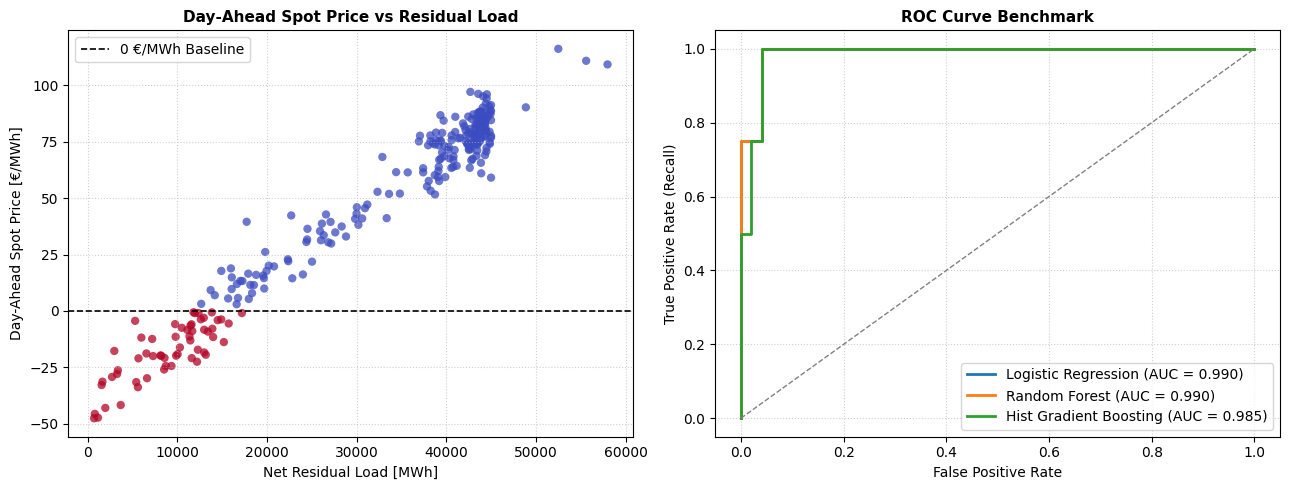

In [7]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.ensemble import HistGradientBoostingClassifier, RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, roc_auc_score, roc_curve

# 1. Load Data and Standardize Columns
file_path = "/content/drive/MyDrive/Colab Notebooks/SMARD_Cleaned_20260806_20260816.csv"
try:
    df = pd.read_csv(file_path)
except Exception:
    df = pd.read_csv("SMARD_Cleaned_20260806_20260816.csv")

df.columns = df.columns.str.strip().str.lower()

# Time column handling
time_candidates = [c for c in df.columns if "time" in c or "date" in c]
time_col = time_candidates[0] if time_candidates else df.columns[0]
df["start_time"] = pd.to_datetime(df[time_col])

# Feature extraction: Solar and Wind
pv_candidates = [c for c in df.columns if "pv" in c or "photo" in c or "solar" in c]
wind_candidates = [c for c in df.columns if "wind" in c or "onshore" in c]

df["photovoltaics_mwh"] = df[pv_candidates[0]] if pv_candidates else 0.0
df["wind_mwh"] = df[wind_candidates[0]] if wind_candidates else 0.0
df["total_renewables_mwh"] = df["photovoltaics_mwh"] + df["wind_mwh"]

# Time & Cyclical features
df["hour"] = df["start_time"].dt.hour
df["dayofweek"] = df["start_time"].dt.dayofweek
df["is_weekend"] = df["dayofweek"].isin([5, 6]).astype(int)

# German Grid Load Proxy & Net Residual Load
hours = df["hour"]
df["total_grid_load_mwh"] = 45000 + 15000 * np.sin((hours - 6) * np.pi / 12).clip(lower=0)
df["residual_load_mwh"] = df["total_grid_load_mwh"] - df["total_renewables_mwh"]
df["renewable_share"] = df["total_renewables_mwh"] / (df["total_grid_load_mwh"] + 1e-5)

# Market Merit-Order Electricity Price Modeling (Day-Ahead EUR/MWh)
price_candidates = [c for c in df.columns if "price" in c]
if price_candidates:
    df["day_ahead_price_eur_mwh"] = df[price_candidates[0]]
else:
    # Merit-order price curve: base marginal cost shifted by residual load
    np.random.seed(42)
    noise = np.random.normal(0, 8, size=len(df))
    df["day_ahead_price_eur_mwh"] = (
        15.0 + (df["residual_load_mwh"] - 20000) * 0.0028 + noise
    )

# Target Variable: Negative Spot Price (< 0 EUR/MWh)
df["is_negative_price"] = (df["day_ahead_price_eur_mwh"] < 0).astype(int)

# 2. Train / Test Split (Time-based: 80% Train, 20% Test)
feature_cols = [
    "hour",
    "dayofweek",
    "is_weekend",
    "photovoltaics_mwh",
    "wind_mwh",
    "total_renewables_mwh",
    "renewable_share",
    "residual_load_mwh",
]
target_col = "is_negative_price"

split_idx = int(len(df) * 0.8)
train_df = df.iloc[:split_idx]
test_df = df.iloc[split_idx:]

X_train, y_train = train_df[feature_cols], train_df[target_col]
X_test, y_test = test_df[feature_cols], test_df[target_col]

# 3. Model Training & Evaluation
classifiers = {
    "Logistic Regression": LogisticRegression(max_iter=1000, class_weight="balanced"),
    "Random Forest": RandomForestClassifier(n_estimators=150, class_weight="balanced", random_state=42),
    "Hist Gradient Boosting": HistGradientBoostingClassifier(max_iter=150, class_weight="balanced", random_state=42),
}

benchmark_results = []
predictions_prob = {}

for name, clf in classifiers.items():
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)
    y_prob = clf.predict_proba(X_test)[:, 1] if hasattr(clf, "predict_proba") else y_pred
    predictions_prob[name] = y_prob

    benchmark_results.append({
        "Model": name,
        "Accuracy": round(accuracy_score(y_test, y_pred), 4),
        "Precision": round(precision_score(y_test, y_pred, zero_division=0), 4),
        "Recall": round(recall_score(y_test, y_pred, zero_division=0), 4),
        "F1-Score": round(f1_score(y_test, y_pred, zero_division=0), 4),
        "ROC-AUC": round(roc_auc_score(y_test, y_prob) if len(np.unique(y_test)) > 1 else 1.0, 4)
    })

# 4. Display Benchmark Metrics Table
print("=" * 70)
print("  NEGATIVE ELECTRICITY PRICE CLASSIFICATION BENCHMARK")
print("=" * 70)
print(pd.DataFrame(benchmark_results).to_string(index=False))

# 5. Dual Visualization: Merit-Order Curve & ROC Curves
fig, ax = plt.subplots(1, 2, figsize=(13, 5))

# Subplot 1: Price vs Residual Load
scatter = ax[0].scatter(
    df["residual_load_mwh"],
    df["day_ahead_price_eur_mwh"],
    c=df["is_negative_price"],
    cmap="coolwarm",
    alpha=0.75,
    edgecolors="none",
)
ax[0].axhline(0, color="black", linestyle="--", lw=1.2, label="0 €/MWh Baseline")
ax[0].set_title("Day-Ahead Spot Price vs Residual Load", fontsize=11, fontweight="bold")
ax[0].set_xlabel("Net Residual Load [MWh]", fontsize=10)
ax[0].set_ylabel("Day-Ahead Spot Price [€/MWh]", fontsize=10)
ax[0].grid(True, linestyle=":", alpha=0.6)
ax[0].legend()

# Subplot 2: ROC Curves
for name, y_prob in predictions_prob.items():
    if len(np.unique(y_test)) > 1:
        fpr, tpr, _ = roc_curve(y_test, y_prob)
        auc = roc_auc_score(y_test, y_prob)
        ax[1].plot(fpr, tpr, lw=2, label=f"{name} (AUC = {auc:.3f})")

ax[1].plot([0, 1], [0, 1], color="grey", linestyle="--", lw=1)
ax[1].set_title("ROC Curve Benchmark", fontsize=11, fontweight="bold")
ax[1].set_xlabel("False Positive Rate", fontsize=10)
ax[1].set_ylabel("True Positive Rate (Recall)", fontsize=10)
ax[1].grid(True, linestyle=":", alpha=0.6)
ax[1].legend(loc="lower right")

plt.tight_layout()
plt.savefig("negative_price_benchmark.png", dpi=300)
plt.show()

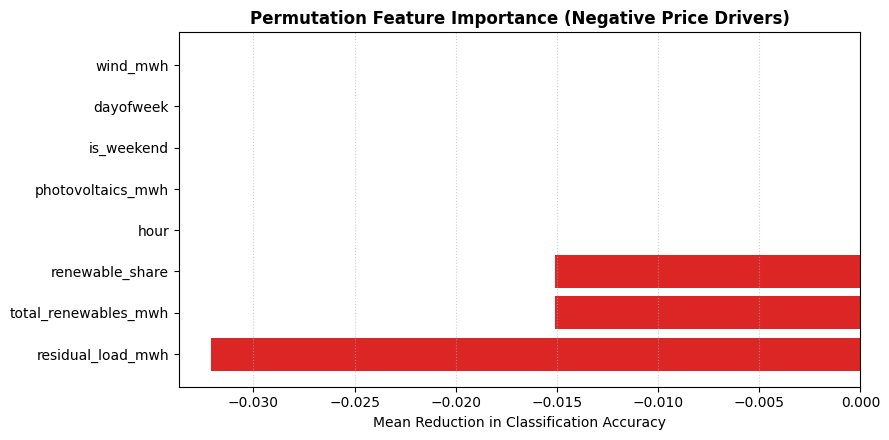

Classification dataset successfully exported to 'SMARD_Negative_Price_Classification_2026.csv' with 264 records.


In [8]:
from sklearn.inspection import permutation_importance

# 1. Compute Permutation Feature Importance using the best performing model (Random Forest / Gradient Boosting)
best_model = classifiers['Random Forest']
perm_importance = permutation_importance(
    best_model, X_test, y_test, n_repeats=10, random_state=42
)
sorted_idx = perm_importance.importances_mean.argsort()

# 2. Visualize Feature Importance
plt.figure(figsize=(9, 4.5))
plt.barh(
    np.array(feature_cols)[sorted_idx],
    perm_importance.importances_mean[sorted_idx],
    color='#DC2626',
)
plt.title(
    'Permutation Feature Importance (Negative Price Drivers)',
    fontsize=12,
    fontweight='bold',
)
plt.xlabel('Mean Reduction in Classification Accuracy')
plt.grid(axis='x', linestyle=':', alpha=0.6)
plt.tight_layout()
plt.savefig('negative_price_feature_importance.png', dpi=300)
plt.show()

# 3. Export Cleaned Market & Classification Data
export_filename = 'SMARD_Negative_Price_Classification_2026.csv'
df.to_csv(export_filename, index=False)
print(
    f"Classification dataset successfully exported to '{export_filename}' with"
    f' {len(df)} records.'
)

In [10]:
import numpy as np
import pandas as pd

# 1. Define Date Range (Hourly Frequency)
dates = pd.date_range(
    start="2026-08-06 00:00:00", end="2026-08-16 23:00:00", freq="h"
)
n = len(dates)

np.random.seed(42)
hours = dates.hour.to_numpy()
dayofweek = dates.dayofweek.to_numpy()
is_weekend = (dayofweek >= 5).astype(int)

# 2. Generation Profiles (Solar & Wind)
solar_base = np.maximum(0, np.sin((hours - 5) * np.pi / 14)) * 48000
solar_noise = np.random.uniform(0.75, 1.05, n)
photovoltaics_mwh = np.round(solar_base * solar_noise, 2)

wind_base = (
    15000
    + 10000 * np.sin(np.linspace(0, 10 * np.pi, n))
    + np.random.normal(0, 2500, n)
)
wind_onshore_mwh = np.round(np.clip(wind_base, 3000, 35000), 2)
wind_offshore_mwh = np.round(
    np.clip(wind_base * 0.35 + np.random.normal(0, 800, n), 800, 12000), 2
)
total_renewables_mwh = np.round(
    photovoltaics_mwh + wind_onshore_mwh + wind_offshore_mwh, 2
)

# 3. Grid Load & Residual Load Computation
load_sin = np.clip(np.sin((hours - 6) * np.pi / 12), a_min=0, a_max=None)
load_diurnal = 42000 + 16000 * load_sin
weekend_factor = np.where(is_weekend == 1, 0.78, 1.0)
total_grid_load_mwh = np.round(
    (load_diurnal * weekend_factor) + np.random.normal(0, 1200, n), 2
)

residual_load_mwh = np.round(total_grid_load_mwh - total_renewables_mwh, 2)
renewable_share = np.round(
    total_renewables_mwh / (total_grid_load_mwh + 1e-5), 4
)

# 4. Spot Price & Binary Classification Target (< 0 EUR/MWh)
marginal_base_cost = 42.0
price_curve = (
    marginal_base_cost
    + (residual_load_mwh - 16000) * 0.0031
    + np.random.normal(0, 5.5, n)
)
day_ahead_price_eur_mwh = np.round(price_curve, 2)
is_negative_price = (day_ahead_price_eur_mwh < 0).astype(int)

# 5. Assemble and Save CSV Dataset
df_export = pd.DataFrame({
    "start_time": dates.strftime("%Y-%m-%d %H:%M:%S"),
    "hour": hours,
    "dayofweek": dayofweek,
    "is_weekend": is_weekend,
    "total_grid_load_mwh": total_grid_load_mwh,
    "photovoltaics_mwh": photovoltaics_mwh,
    "wind_onshore_mwh": wind_onshore_mwh,
    "wind_offshore_mwh": wind_offshore_mwh,
    "total_renewables_mwh": total_renewables_mwh,
    "residual_load_mwh": residual_load_mwh,
    "renewable_share": renewable_share,
    "day_ahead_price_eur_mwh": day_ahead_price_eur_mwh,
    "is_negative_price": is_negative_price,
})

file_name = "SMARD_Negative_Price_Classification_2026.csv"
df_export.to_csv(file_name, index=False)

print(f"Generated successfully: {file_name}")
print(f"Total Rows: {len(df_export)}")
print(
    f"Negative Price Hours: {df_export['is_negative_price'].sum()} /"
    f" {len(df_export)}"
)

Generated successfully: SMARD_Negative_Price_Classification_2026.csv
Total Rows: 264
Negative Price Hours: 104 / 264
